In [26]:
from html import escape
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from matplotlib.patches import Ellipse
from scipy.stats import chi2

# 2D Adaptive Onboarding Example With Dropout

This notebook builds a small synthetic 2D item bank, visualizes its geometry, and compares how the available item-selection policies reduce posterior uncertainty for the same synthetic user.

Unlike the vanilla version, this example includes item-level dropout risk. Sensitive items can be more informative, but they also carry a lower stay probability, so the engagement-aware policies can behave differently from the purely information-seeking policies.

In [ ]:

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.belief import BeliefState
from src.grm import category_probabilities
from src.plots import (
    ACTIVE_BLACK,
    PALETTE,
    POSTERIOR_GREEN,
    PRIOR_BLUE,
    QUESTION_ORANGE,
    STRUCTURE_GRAY,
    apply_notebook_style,
    draw_mean,
    format_axes,
    style_ax,
)
from src.policies import PolicyName, make_sensitive_level_stay_prob
from src.simulate import simulate_episode
from src.synthetic import item_bank_to_dataframe, synthetic_item_bank

apply_notebook_style()

print(f"Using project root: {PROJECT_ROOT}")

Using project root: c:\Users\49160\Adaptive-Onboarding


## Simulation Set Up

Specify number of questions to generate, number of questions that are allowed to be asked and set simulation seed to ensure that all policies encounter the same user.

In [54]:
N_ITEMS = 32
HORIZON = 6
SIMULATION_SEED = 44
theta_true = np.array([0.95, -0.65])  # True user coordinates
prior_belief = BeliefState(
    mu=np.array([0.0, 0.0]),
    Sigma=4.0 * np.eye(2),  # added a 5x prior variance to show that I an very uncertain about the user's true state
)
stay_prob_fn = make_sensitive_level_stay_prob(
    gamma0=0.85,
    gamma_step=0.04,
    min_stay=0.15,
)

POLICIES: list[PolicyName] = [
    "fixed",
    "random",
    "myopic_exact",
    "surrogate_unweighted",
    "surrogate_weighted",
]

## Build A Synthetic 2D Bank

Each item has a discrimination direction `a` in latent space and three thresholds, giving four ordinal response categories. In 2D, the bank is easiest to read as a set of directions on the unit semicircle: items whose normals point in different directions reduce uncertainty along different axes of the posterior ellipse.

In [55]:
item_bank = synthetic_item_bank(
    n_items=N_ITEMS,
    dim=2,
    n_categories=4,
    sensitive_fraction=0.35,
    sensitivity_assignment="random",
    vary_sensitivity_levels=True,
    sensitivity_level_range=(0.65, 1.0),
    rng_seed=6,
    angle_jitter=0.08,
    threshold_span=1.1,
    threshold_perturbation=0.06,
)
item_df = item_bank_to_dataframe(item_bank)

item_df[["item_id", "is_sensitive", "sensitivity_level", "angle", "a_0", "a_1", "threshold_0", "threshold_1", "threshold_2"]].head(8)

,item_id,is_sensitive,sensitivity_level,angle,a_0,a_1,threshold_0,threshold_1,threshold_2
0,item_0000,False,0.000000,0.000300,1.000000,0.000300,-0.979887,-0.021823,1.093022
1,item_0001,False,0.000000,0.096944,0.995305,0.096792,-1.076350,0.104859,1.091097
2,item_0002,False,0.000000,0.195321,0.980985,0.194082,-1.057809,0.005928,1.012172
3,item_0003,False,0.000000,0.293539,0.957226,0.289341,-1.052481,0.061238,1.085601
4,item_0004,False,0.000000,0.396527,0.922408,0.386218,-1.100926,-0.090079,1.008623
5,item_0005,False,0.000000,0.491917,0.881429,0.472316,-1.123491,0.037556,1.071826
6,item_0006,True,0.878900,0.590418,0.830708,0.556708,-1.082479,0.058066,1.105746
7,item_0007,True,0.995638,0.685888,0.773857,0.633360,-1.013128,-0.074762,1.144645


## Item Bank Geometry

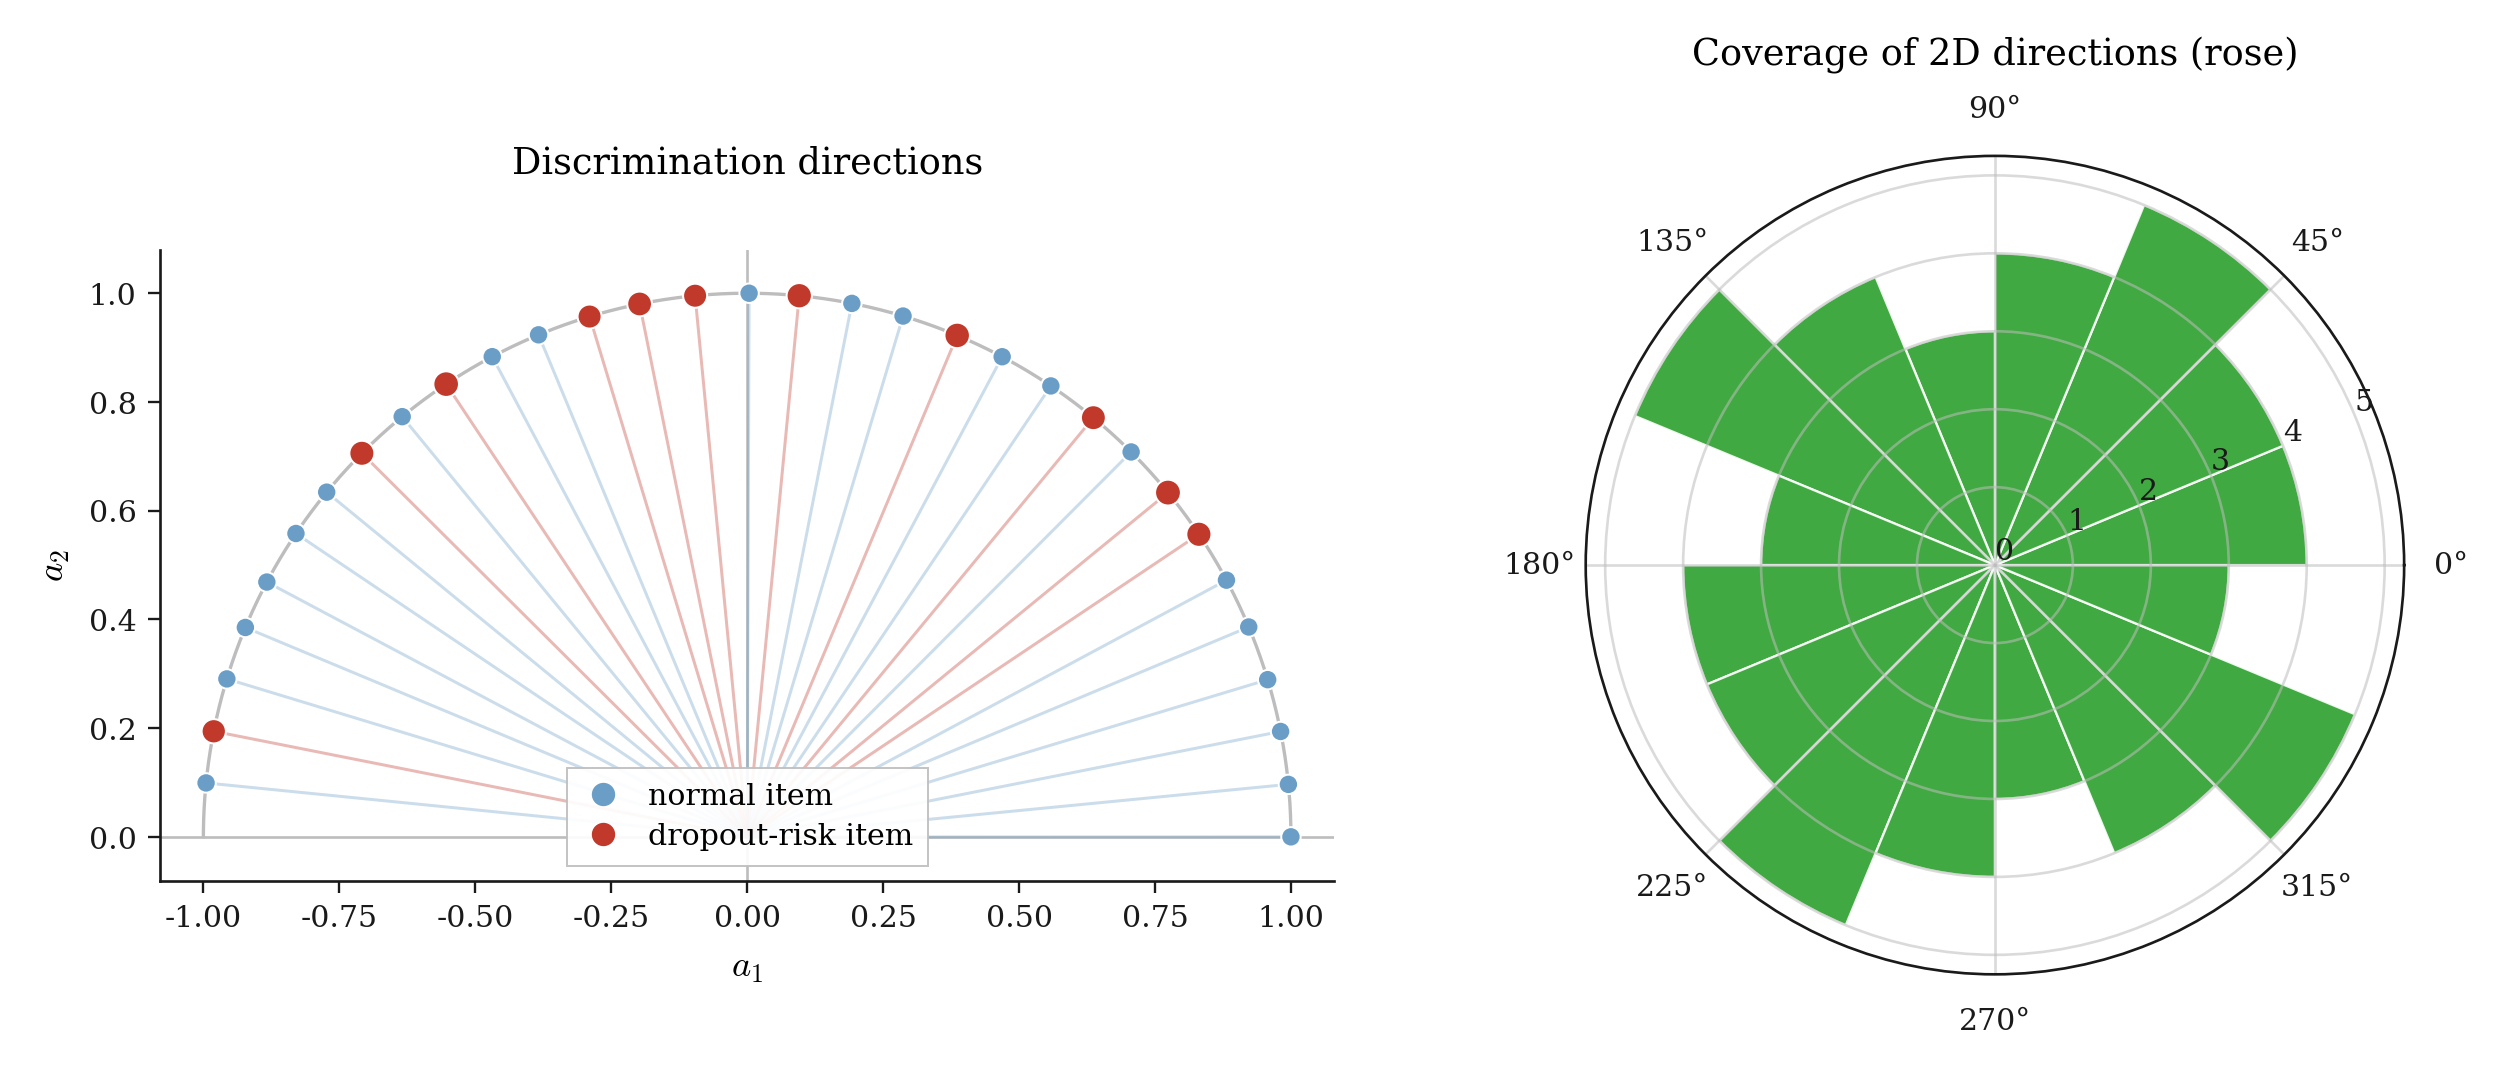

In [56]:
fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 2)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1], projection="polar")]

# Figure 1: Discrimination directions visualized over the unit circle
ax = axes[0]
theta = np.linspace(0, np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color=PALETTE["rule"], linewidth=1.0)
colors = np.where(item_df["is_sensitive"], PALETTE["red"], PRIOR_BLUE)
sizes = 34 + 26 * item_df["sensitivity_level"]
ax.scatter(item_df["a_0"], item_df["a_1"], s=sizes, color=colors, edgecolor="white", linewidth=0.6, zorder=3)
for row in item_df.itertuples():
    color = PALETTE["red"] if row.is_sensitive else PRIOR_BLUE
    ax.plot([0, row.a_0], [0, row.a_1], color=color, alpha=0.35, linewidth=0.9)
ax.axhline(0, color=PALETTE["rule"], linewidth=0.8, zorder=0)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.8, zorder=0)
ax.plot([], [], marker="o", color=PRIOR_BLUE, linestyle="none", label="normal item")
ax.plot([], [], marker="o", color=PALETTE["red"], linestyle="none", label="dropout-risk item")
ax.set_title("Discrimination directions", y=1.08)
ax.set_xlabel(r"$a_1$")
ax.set_ylabel(r"$a_2$")
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-0.08, 1.08)
ax.set_aspect("equal", adjustable="box")
style_ax(ax)
ax.legend(loc="lower center", frameon=True)

# Figure 2: Coverage of 2D directions
ax = axes[1]
angles = np.mod(np.asarray(item_df["angle"], dtype=float), np.pi)
theta_full = np.concatenate([angles, angles + np.pi])
bin_edges = np.linspace(0, 2 * np.pi, 17)
counts, edges = np.histogram(theta_full, bins=bin_edges)
widths = np.diff(edges)

ax.bar(
    edges[:-1], counts, width=widths, align="edge",
    color=POSTERIOR_GREEN, edgecolor="white", linewidth=0.7, alpha=0.9,
)
ax.set_title("Coverage of 2D directions (rose)", y=1.08)
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_yticks(range(0, int(counts.max()) + 1, max(1, int(counts.max()) // 4 or 1)))
ax.grid(True, color=PALETTE["rule"], linewidth=0.8, alpha=0.55)

plt.tight_layout()
plt.show()


## One Shared User And Prior

All policies start from the same prior belief and interact with the same latent user state. Before each answer is sampled, the user may drop out with probability `1 - p_stay(item, step)`. Normal items have stay probability one; sensitive items have lower stay probability according to their `sensitivity_level`.

The fixed `SIMULATION_SEED` below is chosen so no policy drops out in this illustrative run. Dropout risk is still active, so risky choices remain visible through the `stay_prob` column and through the weighted policy's different item choices.

In [57]:

policy_labels = {
    "fixed": "Fixed",
    "random": "Random",
    "myopic_exact": "Myopic exact",
    "surrogate_unweighted": "Surrogate",
    "surrogate_weighted": "Weighted surrogate",
}

episodes = {
    policy: simulate_episode(
        theta_true=theta_true,
        prior_belief=prior_belief,
        item_bank=item_bank,
        strategy=policy,
        horizon=HORIZON,
        stay_prob_fn=stay_prob_fn,
        rng=np.random.default_rng(SIMULATION_SEED),
    )
    for policy in POLICIES
}

summary_rows = []
for policy, result in episodes.items():
    summary_rows.append({
        "Policy": policy_labels[policy],
        "Answered": result.n_answered,
        "Asked": result.n_asked,
        "Progress": f"{result.n_answered}/{result.n_asked}",
        "Dropped out": "Yes" if result.terminated_by_dropout else "No",
        "Final trace": np.trace(result.final_belief.Sigma),
        "Final logdet": np.linalg.slogdet(result.final_belief.Sigma)[1],
        "Asked items": ", ".join(result.asked_item_ids),
    })

summary_df = pd.DataFrame(summary_rows)

trace_max = summary_df["Final trace"].max()
table_rows = []
for row in summary_df.itertuples(index=False):
    trace_width = 100 * row._5 / trace_max if trace_max > 0 else 0
    dropout_class = "dropout-yes" if row._4 == "Yes" else "dropout-no"
    table_rows.append(f"""
        <tr>
            <td class="policy">{escape(row.Policy)}</td>
            <td>{escape(row.Progress)}</td>
            <td class="{dropout_class}">{escape(row._4)}</td>
            <td class="metric-cell">
                <div class="metric-bar" style="width: {trace_width:.1f}%"></div>
                <span>{row._5:.3f}</span>
            </td>
            <td>{row._6:.3f}</td>
            <td class="items">{escape(row._7)}</td>
        </tr>
    """)

display(HTML(f"""
<style>
.policy-summary {{
    border-collapse: collapse;
    width: 100%;
    font-size: 0.92rem;
}}
.policy-summary caption {{
    caption-side: top;
    text-align: left;
    font-weight: 700;
    font-size: 1.05rem;
    margin-bottom: 0.35rem;
}}
.policy-summary th {{
    text-align: left;
    border-bottom: 2px solid {PALETTE['rule']};
    padding: 0.45rem 0.55rem;
}}
.policy-summary td {{
    border-bottom: 1px solid {PALETTE['rule']};
    padding: 0.45rem 0.55rem;
    vertical-align: top;
}}
.policy-summary .policy {{ font-weight: 700; }}
.policy-summary .dropout-no {{ color: #166534; font-weight: 700; }}
.policy-summary .dropout-yes {{ color: #b91c1c; font-weight: 700; }}
.policy-summary .items {{ max-width: 340px; white-space: normal; }}
.policy-summary .metric-cell {{ min-width: 115px; position: relative; }}
.policy-summary .metric-cell span {{ position: relative; z-index: 1; }}
.policy-summary .metric-bar {{
    background: {POSTERIOR_GREEN};
    opacity: 0.18;
    border-radius: 4px;
    inset: 0.25rem auto 0.25rem 0.35rem;
    position: absolute;
}}
</style>
<table class="policy-summary">
    <caption>Policy episode summary</caption>
    <thead>
        <tr>
            <th>Policy</th>
            <th>Answered</th>
            <th>Dropped out</th>
            <th>Final trace</th>
            <th>Final logdet</th>
            <th>Asked items</th>
        </tr>
    </thead>
    <tbody>{''.join(table_rows)}</tbody>
</table>
"""))

Policy,Answered,Dropped out,Final trace,Final logdet,Asked items
Fixed,6/6,No,2.750,-0.639,"item_0000, item_0001, item_0002, item_0003, item_0004, item_0005"
Random,6/6,No,0.995,-1.455,"item_0021, item_0003, item_0031, item_0026, item_0013, item_0029"
Myopic exact,6/6,No,0.706,-2.089,"item_0011, item_0028, item_0020, item_0004, item_0025, item_0008"
Surrogate,5/6,Yes,0.840,-1.756,"item_0005, item_0021, item_0024, item_0008, item_0023, item_0007"
Weighted surrogate,6/6,No,0.675,-2.175,"item_0005, item_0021, item_0025, item_0010, item_0001, item_0016"


## Uncertainty Reduction By Policy

The pale outlines show intermediate posterior covariance ellipses. The blue filled ellipse is the shared prior, the green filled ellipse is the final posterior, and the star is the true latent state. Smaller final ellipses correspond to lower remaining posterior uncertainty.

This is intentionally shown after only six possible questions. With dropout, an aggressive policy can terminate before it gets all six answers. In that case its final ellipse may remain large, not because the selected item was uninformative, but because the user left before answering it.

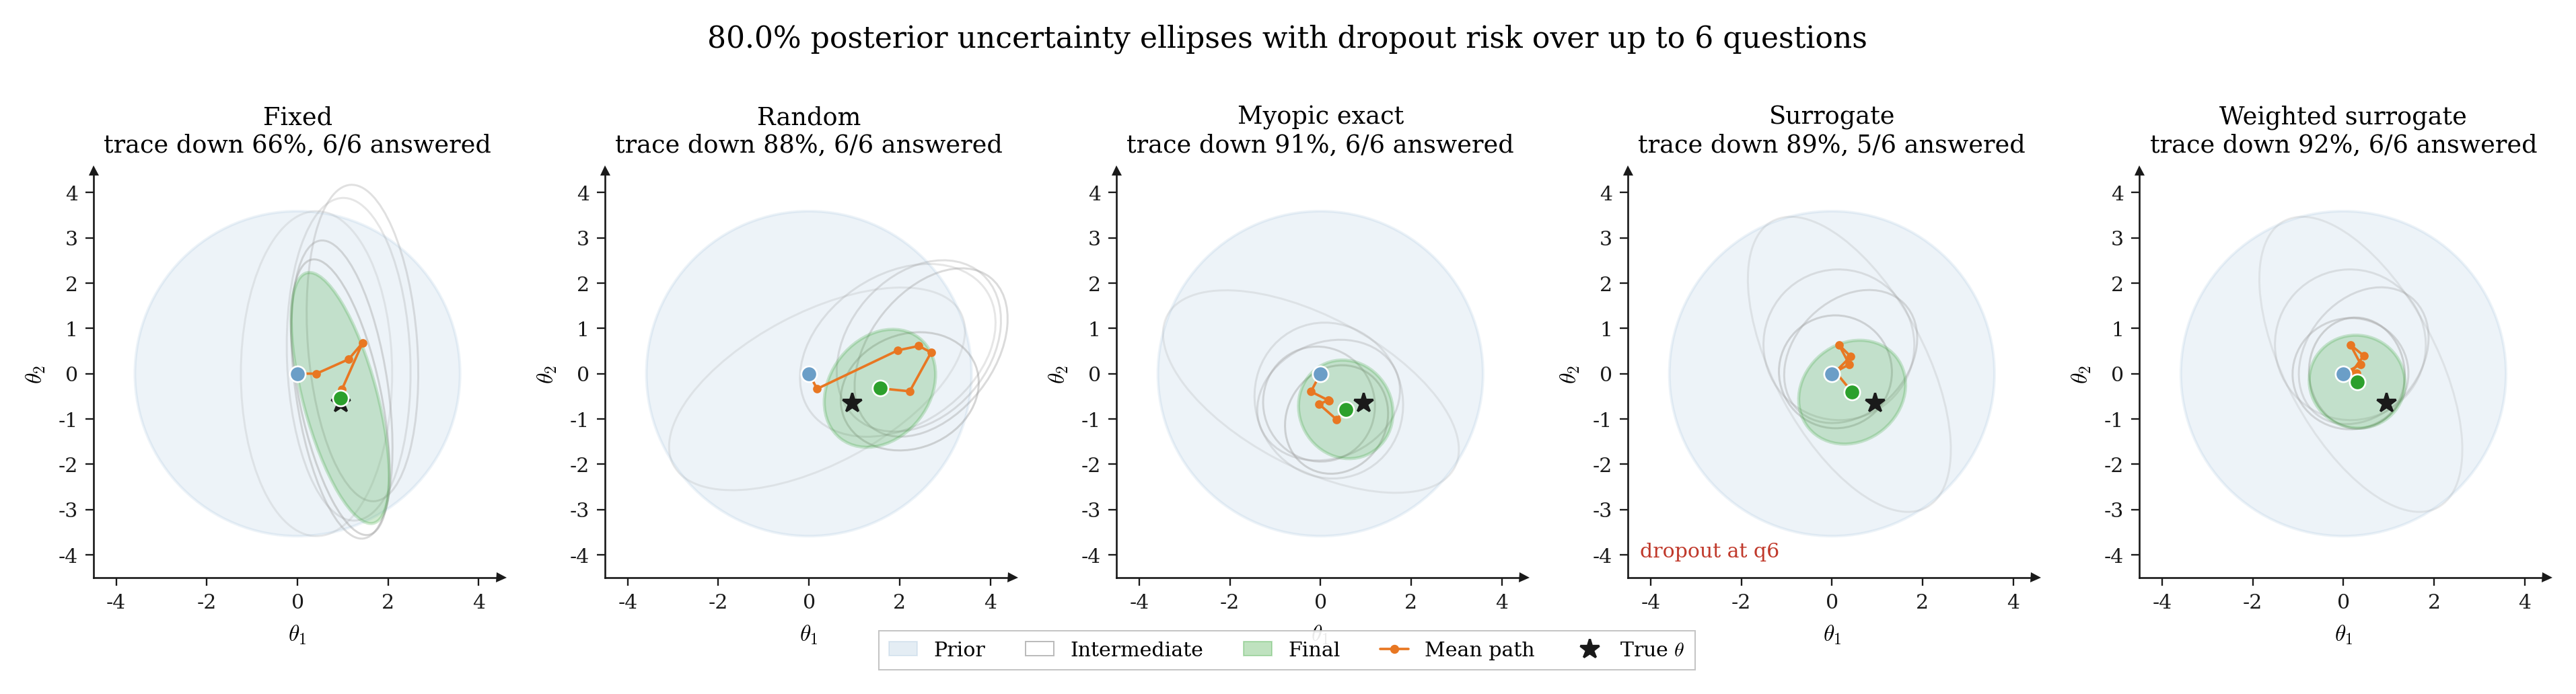

In [60]:
confidence = 0.80
def add_cov_ellipse(ax, mean, cov, *, confidence=confidence, edgecolor=ACTIVE_BLACK,
                    facecolor="none", alpha=1.0, linewidth=1.0, zorder=2,
                    linestyle="-", label=None):
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    radius = np.sqrt(chi2.ppf(confidence, df=2))
    width, height = 2 * radius * np.sqrt(np.maximum(vals, 0.0))
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        linewidth=linewidth,
        linestyle=linestyle,
        zorder=zorder,
        label=label,
    )
    ax.add_patch(ellipse)
    return ellipse


def belief_path(result):
    path = [(prior_belief.mu, prior_belief.Sigma)]
    for step in result.steps:
        if not step.dropped_out:
            path.append((step.belief_mu_after, step.belief_Sigma_after))
    return path


fig, axes = plt.subplots(1, len(POLICIES), figsize=(16, 3.8))
xlim = (-4.5, 4.5)
ylim = (-4.5, 4.5)

for ax, policy in zip(axes, POLICIES):
    result = episodes[policy]
    path = belief_path(result)

    add_cov_ellipse(
        ax, prior_belief.mu, prior_belief.Sigma,
        edgecolor=PRIOR_BLUE, facecolor=PRIOR_BLUE, alpha=0.12,
        linewidth=1.2, zorder=1, label="prior",
    )

    for step_index, (mu, Sigma) in enumerate(path[1:-1], start=1):
        alpha = 0.14 + 0.34 * step_index / max(len(path) - 1, 1)
        add_cov_ellipse(
            ax, mu, Sigma,
            edgecolor=STRUCTURE_GRAY, facecolor="none", alpha=alpha,
            linewidth=0.9, zorder=2,
        )

    final_mu, final_Sigma = path[-1]
    add_cov_ellipse(
        ax, final_mu, final_Sigma,
        edgecolor=POSTERIOR_GREEN, facecolor=POSTERIOR_GREEN, alpha=0.22,
        linewidth=1.4, zorder=3, label="final posterior",
    )

    means = np.array([mu for mu, _ in path])
    ax.plot(means[:, 0], means[:, 1], color=QUESTION_ORANGE, linewidth=1.1, marker="o", markersize=2.8, zorder=4)
    draw_mean(ax, theta_true, kind="true", label=r"true $\theta$", zorder=5)
    draw_mean(ax, prior_belief.mu, kind="prior", zorder=5)
    draw_mean(ax, final_mu, kind="posterior", zorder=5)

    if result.terminated_by_dropout:
        dropout_step = result.steps[-1].step
        ax.text(0.03, 0.04, f"dropout at q{dropout_step + 1}", transform=ax.transAxes,
                color=PALETTE["red"], fontsize=9, ha="left", va="bottom")

    trace0 = np.trace(prior_belief.Sigma)
    traceT = np.trace(final_Sigma)
    reduction = 100 * (1 - traceT / trace0)
    answered = result.n_answered
    ax.set_title(f"{policy_labels[policy]}\ntrace down {reduction:.0f}%, {answered}/{HORIZON} answered")
    format_axes(ax, xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", xlim=xlim, ylim=ylim, equal=False, legend_loc="lower left")
    ax.set_aspect("equal", adjustable="box")

handles = [
    Ellipse((0, 0), 1, 1, edgecolor=PRIOR_BLUE, facecolor=PRIOR_BLUE, alpha=0.18, label="Prior"),
    Ellipse((0, 0), 1, 1, edgecolor=STRUCTURE_GRAY, facecolor="none", alpha=0.7, label="Intermediate"),
    Ellipse((0, 0), 1, 1, edgecolor=POSTERIOR_GREEN, facecolor=POSTERIOR_GREEN, alpha=0.30, label="Final"),
    plt.Line2D([], [], color=QUESTION_ORANGE, marker="o", markersize=3, linewidth=1.1, label="Mean path"),
    plt.Line2D([], [], color=ACTIVE_BLACK, marker="*", markersize=9, linestyle="none", label=r"True $\theta$"),
]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"{confidence*100}% posterior uncertainty ellipses with dropout risk over up to {HORIZON} questions", y=1.03)
plt.tight_layout()
plt.show()

## Uncertainty Curves

The ellipse panel is geometric but not always perceptually fair. These curves expose the step-by-step contraction and stop when a policy loses the user. The weighted surrogate now differs from the unweighted surrogate because sensitive items have lower stay probability.

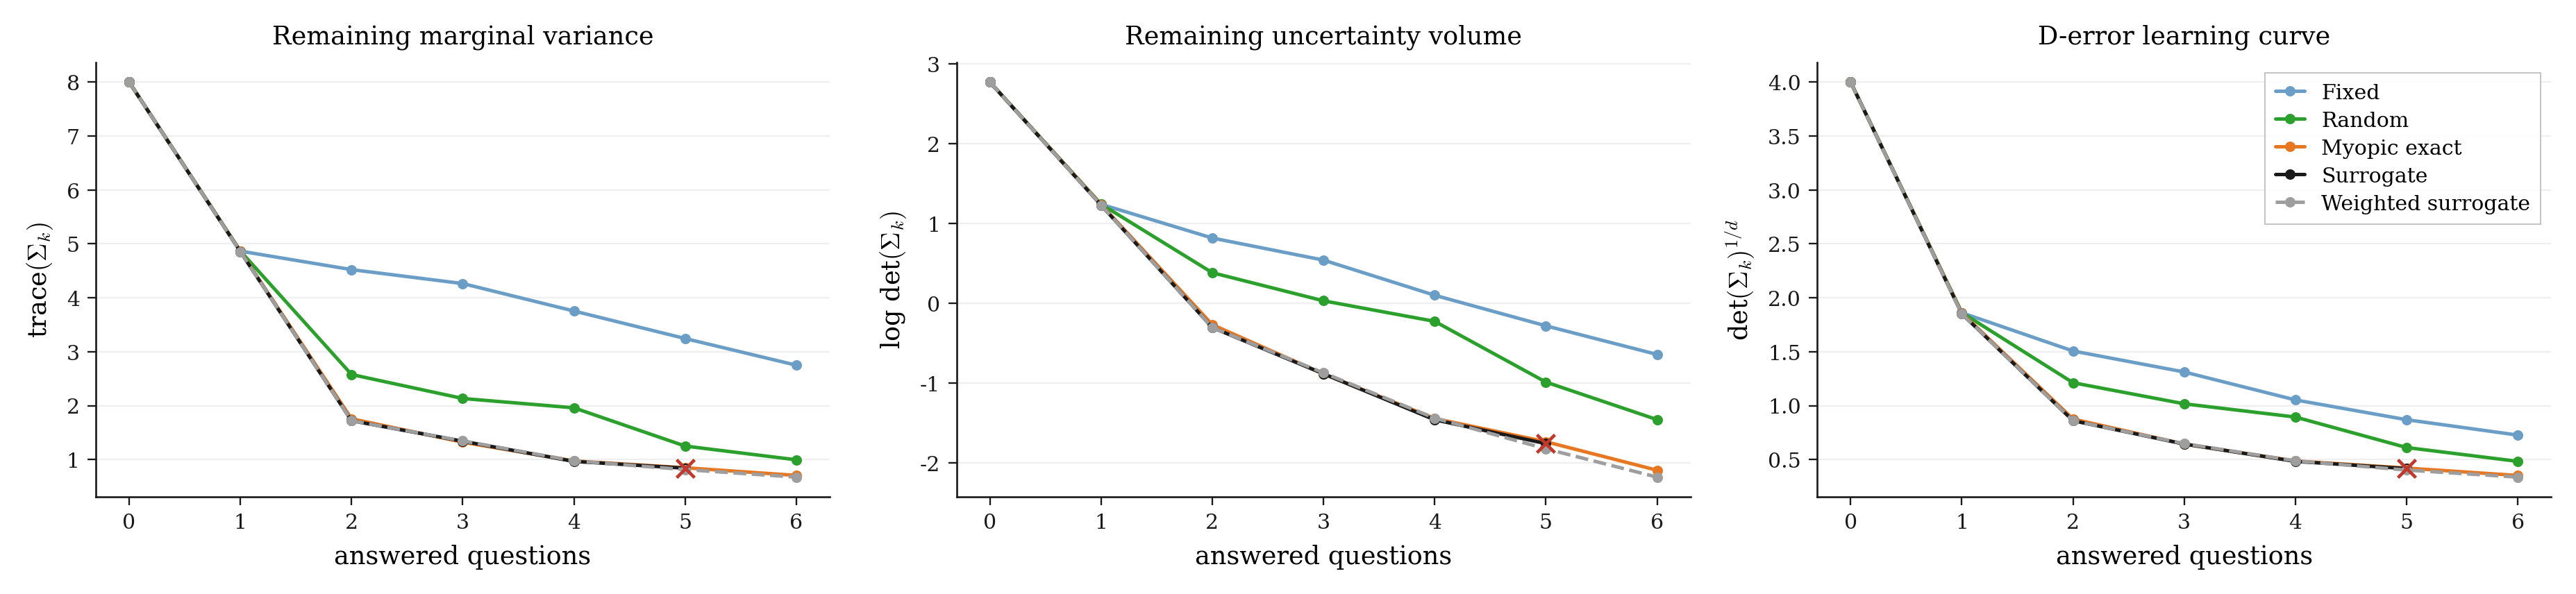

In [61]:
def uncertainty_series(result):
    covs = [prior_belief.Sigma]
    for step in result.steps:
        if step.dropped_out:
            break
        covs.append(step.belief_Sigma_after)
    traces = np.array([float(np.trace(Sigma)) for Sigma in covs])
    logdets = np.array([float(np.linalg.slogdet(Sigma)[1]) for Sigma in covs])
    d_errors = np.exp(logdets / prior_belief.dim)
    return np.arange(len(covs)), traces, logdets, d_errors


fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.6))

for policy in POLICIES:
    result = episodes[policy]
    x, traces, logdets, d_errors = uncertainty_series(result)
    label = policy_labels[policy]
    linestyle = "--" if policy == "surrogate_weighted" else "-"
    axes[0].plot(x, traces, marker="o", markersize=3.5, linewidth=1.5, linestyle=linestyle, label=label)
    axes[1].plot(x, logdets, marker="o", markersize=3.5, linewidth=1.5, linestyle=linestyle, label=label)
    axes[2].plot(x, d_errors, marker="o", markersize=3.5, linewidth=1.5, linestyle=linestyle, label=label)
    if result.terminated_by_dropout:
        axes[0].scatter(x[-1], traces[-1], marker="x", s=60, color=PALETTE["red"], zorder=5)
        axes[1].scatter(x[-1], logdets[-1], marker="x", s=60, color=PALETTE["red"], zorder=5)
        axes[2].scatter(x[-1], d_errors[-1], marker="x", s=60, color=PALETTE["red"], zorder=5)

axes[0].set_title("Remaining marginal variance")
axes[0].set_xlabel("answered questions")
axes[0].set_ylabel(r"trace$(\Sigma_k)$")
style_ax(axes[0], grid_axis="y")

axes[1].set_title("Remaining uncertainty volume")
axes[1].set_xlabel("answered questions")
axes[1].set_ylabel(r"log det$(\Sigma_k)$")
style_ax(axes[1], grid_axis="y")

axes[2].set_title("D-error learning curve")
axes[2].set_xlabel("answered questions")
axes[2].set_ylabel(r"det$(\Sigma_k)^{1/d}$")
style_ax(axes[2], grid_axis="y")
axes[2].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()



## Policy Step Audit

This table keeps the geometric figure auditable in a policy-by-step format. Each step cell shows the selected item, sensitivity/dropout information, the response predicted before the update, the response actually sampled, and the posterior trace before and after the answer.


In [62]:
required_names = ["item_bank", "episodes", "policy_labels", "HORIZON"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Run the setup and simulation cells above before this audit table. "
        f"Missing: {', '.join(missing_names)}"
    )

item_by_id = {item.item_id: item for item in item_bank}


def step_audit_fields(step):
    item = item_by_id[step.item_id]
    trace_before = float(np.trace(step.belief_Sigma_before))

    if step.dropped_out:
        return {
            "item": step.item_id,
            "sensitive": item.is_sensitive,
            "stay_prob": step.stay_prob,
            "dropped_out": True,
            "expected_response": None,
            "expected_prob": None,
            "received_response": None,
            "trace_before": trace_before,
            "trace_after": None,
        }

    belief_before = BeliefState(mu=step.belief_mu_before, Sigma=step.belief_Sigma_before)
    probs = category_probabilities(belief_before, item)
    expected_response = int(np.argmax(probs))
    received_response = int(step.response)

    return {
        "item": step.item_id,
        "sensitive": item.is_sensitive,
        "stay_prob": step.stay_prob,
        "dropped_out": False,
        "expected_response": expected_response,
        "expected_prob": float(probs[expected_response]),
        "received_response": received_response,
        "trace_before": trace_before,
        "trace_after": float(np.trace(step.belief_Sigma_after)),
    }


def format_step_cell(fields):
    if fields is None:
        return '<span class="muted">not reached</span>'

    dropped = "yes" if fields["dropped_out"] else "no"
    sensitive = "yes" if fields["sensitive"] else "no"
    expected = (
        "dropout before answer"
        if fields["expected_response"] is None
        else f"{fields['expected_response']} (p={fields['expected_prob']:.3f})"
    )
    received = "-" if fields["received_response"] is None else str(fields["received_response"])
    trace_after = "-" if fields["trace_after"] is None else f"{fields['trace_after']:.3f}"
    dropout_class = "dropout-yes" if fields["dropped_out"] else "dropout-no"
    sensitive_class = "sensitive-yes" if fields["sensitive"] else "sensitive-no"

    return f"""
        <div class="step-card {dropout_class}">
            <div><span class="key">item</span> <span class="item-id">{escape(fields['item'])}</span></div>
            <div><span class="key">sensitive</span> <span class="{sensitive_class}">{sensitive}</span></div>
            <div><span class="key">stay prob</span> {fields['stay_prob']:.2f}</div>
            <div><span class="key">dropped</span> {dropped}</div>
            <div><span class="key">expected</span> {escape(expected)}</div>
            <div><span class="key">received</span> {escape(received)}</div>
            <div><span class="key">trace</span> {fields['trace_before']:.3f} -> {trace_after}</div>
        </div>
    """


max_recorded_step = max(
    (step.step for result in episodes.values() for step in result.steps),
    default=-1,
)
audit_step_count = max(HORIZON, max_recorded_step + 1)

header_cells = "".join(f"<th>Step {step + 1}</th>" for step in range(audit_step_count))
body_rows = []
for policy in POLICIES:
    result = episodes[policy]
    fields_by_step = {step.step: step_audit_fields(step) for step in result.steps}
    step_cells = "".join(
        f"<td>{format_step_cell(fields_by_step.get(step))}</td>"
        for step in range(audit_step_count)
    )
    body_rows.append(
        f"<tr><th class='policy-col'>{escape(policy_labels[policy])}</th>{step_cells}</tr>"
    )

audit_html = f"""
<style>
.policy-step-audit {{
    border-collapse: separate;
    border-spacing: 0;
    width: 100%;
    font-size: 12px;
    line-height: 1.32;
}}
.policy-step-audit th,
.policy-step-audit td {{
    border-bottom: 1px solid #e6e1d8;
    border-right: 1px solid #eee9e1;
    padding: 7px 8px;
    vertical-align: top;
}}
.policy-step-audit thead th {{
    background: #f7f4ee;
    color: #2f2f2f;
    font-weight: 650;
    text-align: left;
    position: sticky;
    top: 0;
    z-index: 1;
}}
.policy-step-audit .policy-col {{
    background: #fbfaf7;
    color: #1f1f1f;
    font-weight: 700;
    min-width: 132px;
    text-align: left;
}}
.policy-step-audit td {{
    min-width: 150px;
}}
.step-card {{
    border-left: 3px solid #8fa88f;
    padding-left: 7px;
}}
.step-card.dropout-yes {{
    border-left-color: #c45f4f;
}}
.key {{
    color: #746e65;
    display: inline-block;
    min-width: 68px;
}}
.item-id {{
    font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
}}
.sensitive-yes,
.dropout-yes {{
    color: #9d3f32;
    font-weight: 650;
}}
.sensitive-no,
.dropout-no {{
    color: #2f6f55;
}}
.muted {{
    color: #9a948b;
    font-style: italic;
}}
.audit-scroll {{
    overflow-x: auto;
    padding-bottom: 4px;
}}
</style>
<div class="audit-scroll">
<table class="policy-step-audit">
    <thead><tr><th>Policy</th>{header_cells}</tr></thead>
    <tbody>{''.join(body_rows)}</tbody>
</table>
</div>
"""

display(HTML(audit_html))



Policy,Step 1,Step 2,Step 3,Step 4,Step 5,Step 6
Fixed,item item_0000 sensitive no stay prob 1.00 dropped no expected 0 (p=0.331) received 2 trace 8.000 -> 4.866,item item_0001 sensitive no stay prob 1.00 dropped no expected 3 (p=0.312) received 3 trace 4.866 -> 4.522,item item_0002 sensitive no stay prob 1.00 dropped no expected 3 (p=0.549) received 3 trace 4.522 -> 4.264,item item_0003 sensitive no stay prob 1.00 dropped no expected 3 (p=0.648) received 1 trace 4.264 -> 3.755,item item_0004 sensitive no stay prob 1.00 dropped no expected 3 (p=0.422) received 2 trace 3.755 -> 3.245,item item_0005 sensitive no stay prob 1.00 dropped no expected 3 (p=0.344) received 2 trace 3.245 -> 2.750
Random,item item_0021 sensitive no stay prob 1.00 dropped no expected 0 (p=0.320) received 1 trace 8.000 -> 4.867,item item_0003 sensitive no stay prob 1.00 dropped no expected 3 (p=0.323) received 3 trace 4.867 -> 2.577,item item_0031 sensitive no stay prob 1.00 dropped no expected 0 (p=0.691) received 0 trace 2.577 -> 2.132,item item_0026 sensitive no stay prob 1.00 dropped no expected 0 (p=0.673) received 0 trace 2.132 -> 1.960,item item_0013 sensitive no stay prob 1.00 dropped no expected 3 (p=0.536) received 1 trace 1.960 -> 1.250,item item_0029 sensitive no stay prob 1.00 dropped no expected 0 (p=0.826) received 1 trace 1.250 -> 0.995
Myopic exact,item item_0011 sensitive no stay prob 1.00 dropped no expected 0 (p=0.309) received 1 trace 8.000 -> 4.863,item item_0028 sensitive no stay prob 1.00 dropped no expected 3 (p=0.316) received 1 trace 4.863 -> 1.756,item item_0020 sensitive no stay prob 1.00 dropped no expected 0 (p=0.352) received 1 trace 1.756 -> 1.322,item item_0004 sensitive no stay prob 1.00 dropped no expected 2 (p=0.295) received 1 trace 1.322 -> 0.974,item item_0025 sensitive no stay prob 1.00 dropped no expected 1 (p=0.381) received 0 trace 0.974 -> 0.848,item item_0008 sensitive no stay prob 1.00 dropped no expected 1 (p=0.345) received 2 trace 0.848 -> 0.706
Surrogate,item item_0005 sensitive no stay prob 1.00 dropped no expected 3 (p=0.316) received 2 trace 8.000 -> 4.857,item item_0021 sensitive no stay prob 1.00 dropped no expected 0 (p=0.319) received 2 trace 4.857 -> 1.720,item item_0024 sensitive yes stay prob 0.34 dropped no expected 2 (p=0.314) received 1 trace 1.720 -> 1.340,item item_0008 sensitive no stay prob 1.00 dropped no expected 3 (p=0.355) received 1 trace 1.340 -> 0.965,item item_0023 sensitive no stay prob 1.00 dropped no expected 1 (p=0.335) received 0 trace 0.965 -> 0.840,item item_0007 sensitive yes stay prob 0.35 dropped yes expected dropout before answer received - trace 0.840 -> -
Weighted surrogate,item item_0005 sensitive no stay prob 1.00 dropped no expected 3 (p=0.316) received 2 trace 8.000 -> 4.857,item item_0021 sensitive no stay prob 1.00 dropped no expected 0 (p=0.319) received 2 trace 4.857 -> 1.720,item item_0025 sensitive no stay prob 1.00 dropped no expected 2 (p=0.292) received 1 trace 1.720 -> 1.345,item item_0010 sensitive no stay prob 1.00 dropped no expected 3 (p=0.368) received 1 trace 1.345 -> 0.976,item item_0001 sensitive no stay prob 1.00 dropped no expected 1 (p=0.326) received 2 trace 0.976 -> 0.814,item item_0016 sensitive no stay prob 1.00 dropped no expected 2 (p=0.337) received 1 trace 0.814 -> 0.675
